In [4]:
import pandas as pd
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np



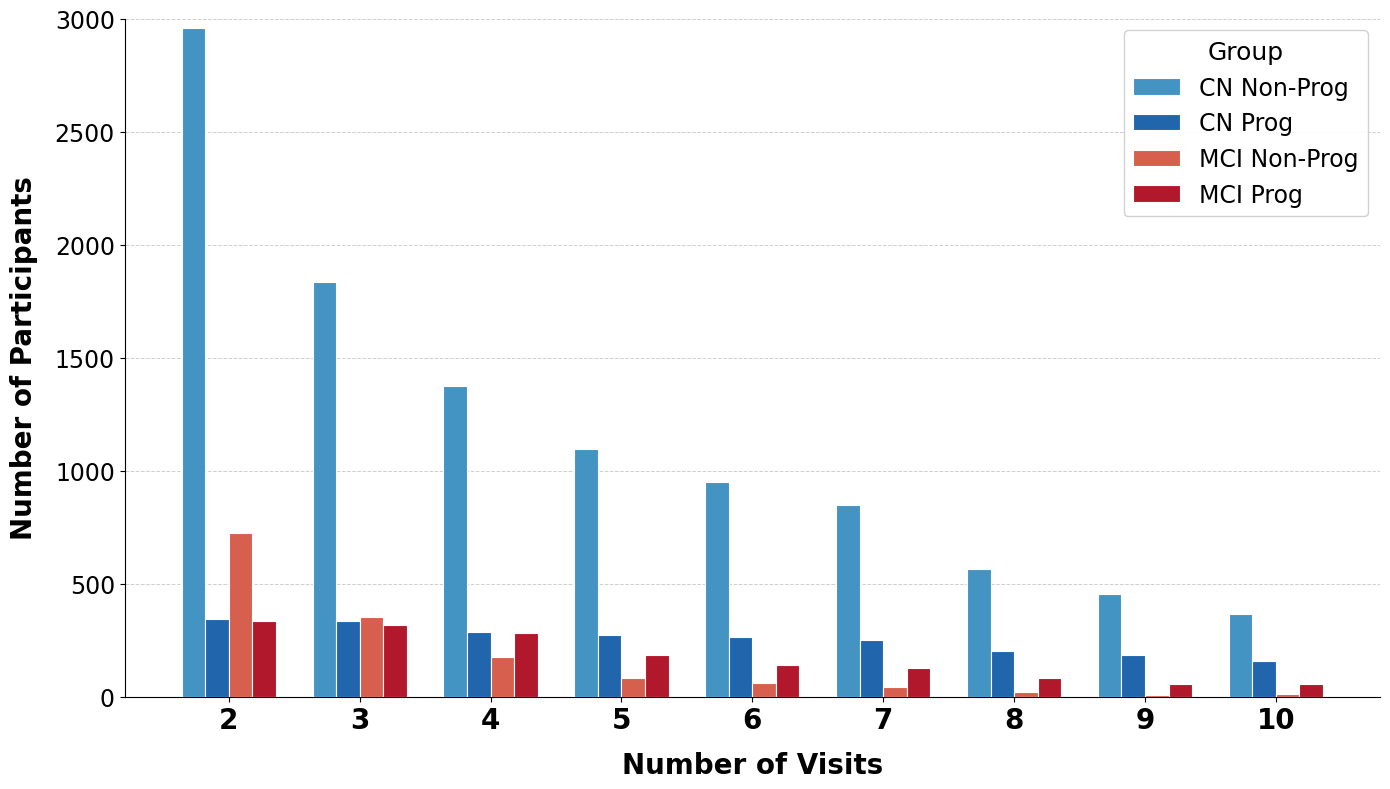

Saved → poster_group_barchart.png
                  CN Non-Prog  CN Prog  MCI Non-Prog  MCI Prog
Number of Visits                                              
2 Visits                 2958      342           726       333
3 Visits                 1835      334           353       317
4 Visits                 1373      287           174       280
5 Visits                 1095      272            81       185
6 Visits                  951      264            59       138
7 Visits                  847      250            41       127
8 Visits                  566      200            20        83
9 Visits                  453      185             9        58
10 Visits                 367      158            11        56
Saved → group_visit_counts.xlsx


In [15]:
import ast

# ── Load data ──────────────────────────────────────────────────────────────────
cn_df  = pd.read_csv("datasets/Dataset_v2/pooled_CN.csv")
lead_time_cn_df  = pd.read_csv("datasets/Dataset_v2/lead_time_CN.csv")
mci_df = pd.read_csv("datasets/Dataset_v2/pooled_MCI_AD.csv")
lead_time_mci_df = pd.read_csv("datasets/Dataset_v2/lead_time_MCI_AD.csv")

def parse_prog(s):
    return ast.literal_eval(s)

for df in [cn_df, lead_time_cn_df, mci_df, lead_time_mci_df]:
    df["prog_tuple"] = df["Progression"].apply(parse_prog)
    df["n_visits"]   = df["prog_tuple"].apply(len)

cn_df["is_progressor"]          = cn_df["prog_tuple"].apply(lambda t: any(x != 0 for x in t))
lead_time_cn_df["is_progressor"]= lead_time_cn_df["prog_tuple"].apply(lambda t: any(x != 0 for x in t))
mci_df["is_progressor"]         = mci_df["prog_tuple"].apply(lambda t: any(x == 2 for x in t))
lead_time_mci_df["is_progressor"]= lead_time_mci_df["prog_tuple"].apply(lambda t: any(x == 2 for x in t))

# ── Combine pooled + lead_time DataFrames ──────────────────────────────────────
combined_cn_df  = pd.concat([cn_df, lead_time_cn_df], ignore_index=True)
combined_mci_df = pd.concat([mci_df, lead_time_mci_df], ignore_index=True)

visit_counts = [2, 3, 4, 5, 6, 7, 8, 9, 10]

groups = {
    "CN Non-Prog":  combined_cn_df[~combined_cn_df["is_progressor"]],
    "CN Prog":      combined_cn_df[combined_cn_df["is_progressor"]],
    "MCI Non-Prog": combined_mci_df[~combined_mci_df["is_progressor"]],
    "MCI Prog":     combined_mci_df[combined_mci_df["is_progressor"]],
}

counts = {
    label: [int((df["n_visits"] == v).sum()) for v in visit_counts]
    for label, df in groups.items()
}

colors = ["#4393C3", "#2166AC", "#D6604D", "#B2182B"]

fig, ax = plt.subplots(figsize=(14, 8))

n_groups = len(visit_counts)
n_bars   = len(groups)
bar_w    = 0.18
x        = np.arange(n_groups)

for i, (label, color) in enumerate(zip(groups.keys(), colors)):
    offsets = x + (i - (n_bars - 1) / 2) * bar_w
    bars = ax.bar(offsets, counts[label], bar_w,
                  label=label, color=color, edgecolor="white", linewidth=0.8, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([f"{v}" for v in visit_counts], fontsize=20, fontweight="bold")
ax.set_ylabel("Number of Participants", fontsize=20, fontweight="bold", labelpad=12)
ax.set_xlabel("Number of Visits", fontsize=20, fontweight="bold", labelpad=12)

ax.set_ylim(0, 3000)
ax.set_yticks(range(0, 3001, 500))

ax.tick_params(axis="y", labelsize=17)
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

legend = ax.legend(
    title="Group", title_fontsize=18,
    fontsize=17, frameon=True, framealpha=0.9,
    edgecolor="#cccccc", loc="upper right"
)

plt.tight_layout()
plt.savefig("poster_group_barchart.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → poster_group_barchart.png")

summary = pd.DataFrame(counts, index=[f"{v} Visits" for v in visit_counts])
summary.index.name = "Number of Visits"
print(summary)

summary.to_excel("group_visit_counts.xlsx")
print("Saved → group_visit_counts.xlsx")
